In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [46]:
bc_activities = pd.read_csv("../../output/NKX2-2/TL4B2/rim/err_corr_100/bc_activities.csv")
bc_activities["log_activity"] = np.log(bc_activities["RTBC_umi_count_simple"] / bc_activities["AD_umi_count_simple"])
bc_activities

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ADBC2,HawkBCs,RTBC,AD,time,rep,AD_umi_count_simple,RTBC_umi_count_simple,activity,log_activity
0,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,1,197.0,81.0,0.411168,-0.888755
1,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,2,1537.0,1166.0,0.758621,-0.276253
2,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0ND,1,0.0,22.0,inf,inf
3,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0ND,2,21.0,183.0,8.714286,2.164964
4,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,24,1,92.0,269.0,2.923913,1.072923
...,...,...,...,...,...,...,...,...,...,...
14988,TTTTGC,AGCACAGGA,GAGACAGATGAATTGG,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,3,223.0,128.0,0.573991,-0.555142
14989,TTTTGC,AGCACAGGA,GAGACAGATGAATTGG,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,4,27.0,0.0,0.000000,-inf
14990,TTTTGC,AGCACAGGA,GAGACAGATGAATTGG,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,6,1,6112.0,9001.0,1.472677,0.387082
14991,TTTTGC,AGCACAGGA,GAGACAGATGAATTGG,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,6,2,878.0,2907.0,3.310934,1.197230


In [47]:
AD_activities = bc_activities[["AD", "time", "rep", "activity", "log_activity"]].groupby(["AD", "time", "rep"])[["activity", "log_activity"]].agg([np.mean, np.std]).reset_index().dropna()
AD_activities.columns = ["AD", "time", "rep", "mean(activity)", "std(activity)", "mean(log_activity)", "std(log_activity)"]
AD_activities["time"] = AD_activities["time"].replace("0ND", "-1").astype(int)
AD_activities = AD_activities.sort_values(by = ["time", "rep"])
AD_activities

/tmp/ipykernel_281194/836162923.py:1: FutureWarning: The provided callable <function mean at 0x14debcd5c2c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  AD_activities = bc_activities[["AD", "time", "rep", "activity", "log_activity"]].groupby(["AD", "time", "rep"])[["activity", "log_activity"]].agg([np.mean, np.std]).reset_index().dropna()
/tmp/ipykernel_281194/836162923.py:1: FutureWarning: The provided callable <function std at 0x14debcd5c400> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  AD_activities = bc_activities[["AD", "time", "rep", "activity", "log_activity"]].groupby(["AD", "time", "rep"])[["activity", "log_activity"]].agg([np.mean, np.std]).reset_index().dropna()
/tmp/ipykernel_281194/836162923.py:1: FutureWarning: The prov

,AD,time,rep,mean(activity),std(activity),mean(log_activity),std(log_activity)
172,AGCACCGCTCCTCCCACCGACGTGAGCCTGGGCGACGAGCTGCACC...,-1,1,14.683114,9.672583,2.499951,0.722294
251,CAGTACAACGCCCAGTACAGCAGCGCCAGCACACCTCAGCCCTTCA...,-1,1,10.077804,6.428859,2.126096,0.704509
338,CAGTTCGCCCTGACCGCCGCCGACGCCCAGGCCGGCATTCCCTTCA...,-1,1,14.790841,11.018960,2.474940,0.771558
362,CCCACCGACGTGAGCCTGGGCGACGAGCTGCACCTGGACGGCGAGG...,-1,1,19.414000,15.099923,2.776796,0.732308
528,CTGCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,-1,1,14.894444,4.957604,2.672494,0.339208
...,...,...,...,...,...,...,...
4478,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,48,3,1.394384,0.225992,0.321373,0.168564
1446,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCGACTTCA...,48,4,0.001297,0.000389,-6.686225,0.334071
2096,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,4,0.001393,0.000799,-6.752382,0.692984
3413,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,4,0.023851,0.008172,-3.766178,0.349590


In [48]:
len(AD_activities["time"].unique())

6

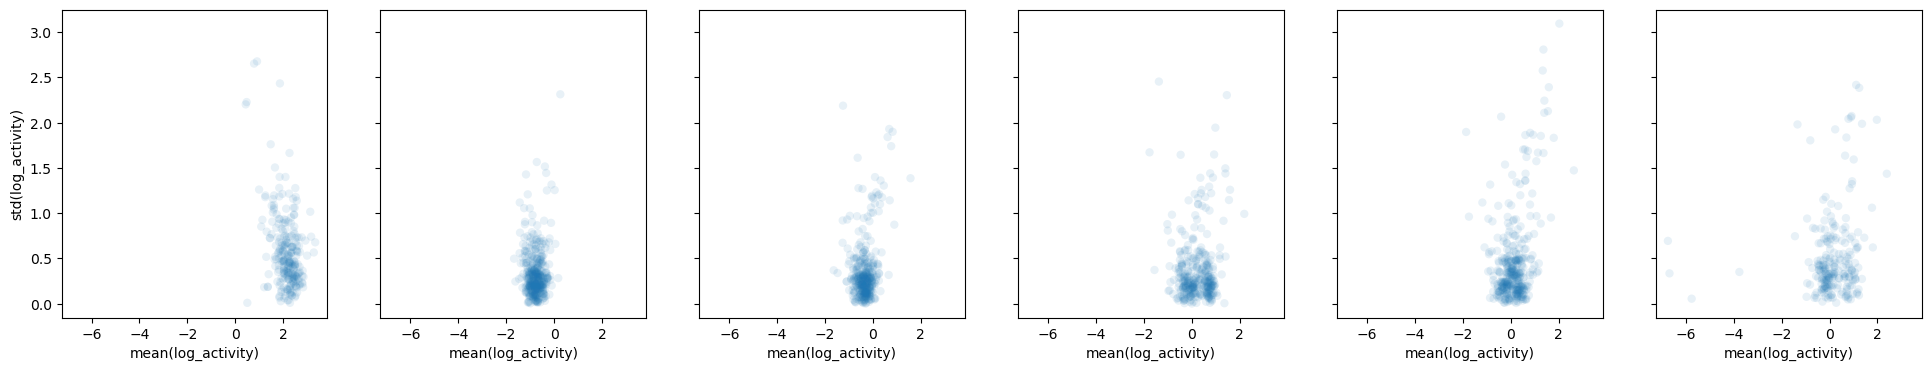

In [51]:
fig, axs = plt.subplots(1,6, figsize = (24,4), sharex = True, sharey = True)
for ax, time in zip(axs, AD_activities["time"].unique()):
    sns.scatterplot(data = AD_activities[AD_activities["time"] == time], x = "mean(log_activity)", y = "std(log_activity)", ax = ax, edgecolor = 'none', alpha = 0.1)


<Axes: xlabel='mean(log_activity)', ylabel='std(log_activity)'>

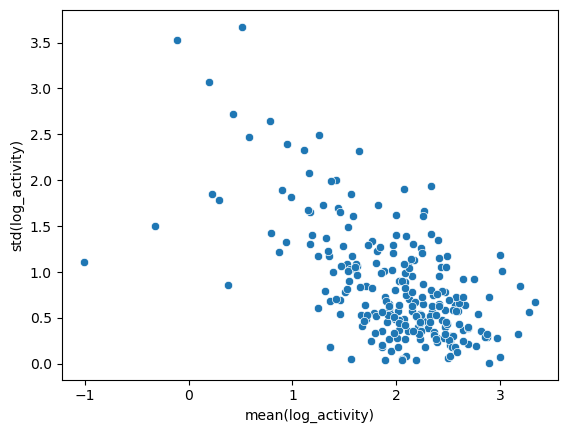

In [29]:
sns.scatterplot(data = AD_activities[AD_activities["time"] == "0ND"], x = "mean(log_activity)", y = "std(log_activity)")

<Axes: xlabel='mean(log_activity)', ylabel='std(log_activity)'>

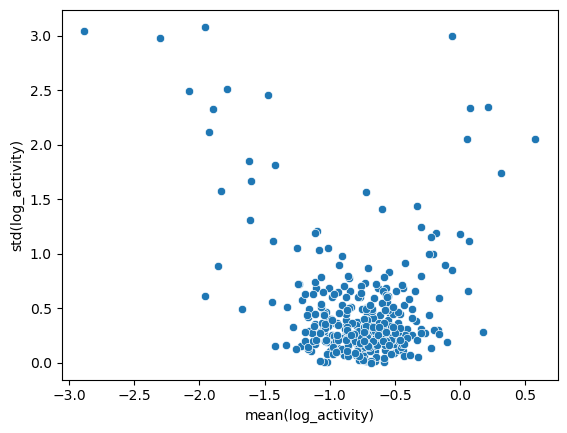

In [26]:
sns.scatterplot(data = AD_activities[AD_activities["time"] == "0"], x = "mean(log_activity)", y = "std(log_activity)")

<Axes: xlabel='mean(log_activity)', ylabel='std(log_activity)'>

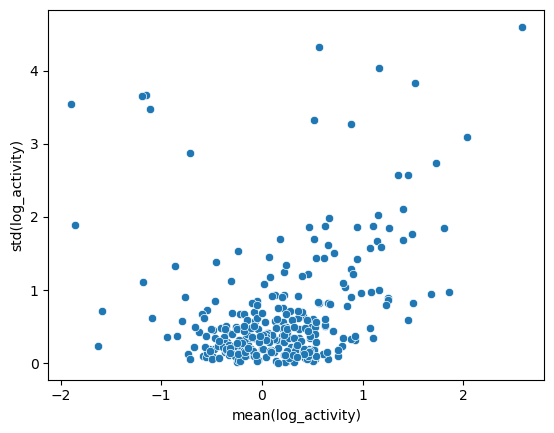

In [28]:
sns.scatterplot(data = AD_activities[AD_activities["time"] == "24"], x = "mean(log_activity)", y = "std(log_activity)")

<Axes: xlabel='mean(log_activity)', ylabel='std(log_activity)'>

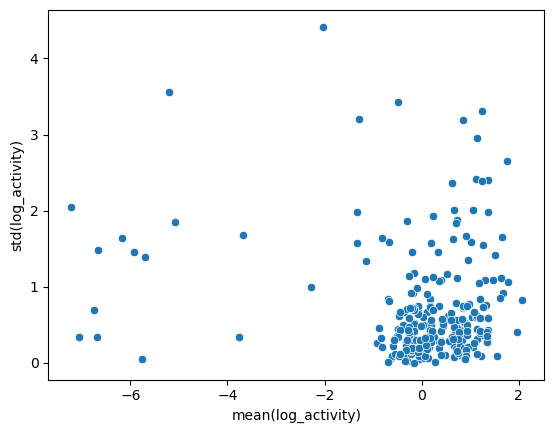

In [27]:
sns.scatterplot(data = AD_activities[AD_activities["time"] == "48"], x = "mean(log_activity)", y = "std(log_activity)")